In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
#Libraries
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (accuracy_score,precision_score,
    recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,
    precision_recall_curve,roc_curve)

In [12]:
#LOAD DATA
BASE_PATH = "/content/drive/MyDrive/d2c_churn/data/"
df = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")
print("Shape:",df.shape)
df.head()

Shape: (2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [13]:
#Intial checking
print('\n Info\n',df.info())
print('\n Null values\n',df.isnull().sum().sort_values(ascending=False))
print('\n Describe\n',df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   object 
 1   snapshot_date             2400 non-null   object 
 2   city_tier                 2400 non-null   object 
 3   age_group                 2400 non-null   object 
 4   acquisition_channel       2400 non-null   object 
 5   loyalty_tier              1014 non-null   object 
 6   preferred_category        2400 non-null   object 
 7   marketing_consent         2400 non-null   object 
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category


 The value counts of churn_next_60d
 churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

 The percentage of value counts of churn_next_60d
 churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


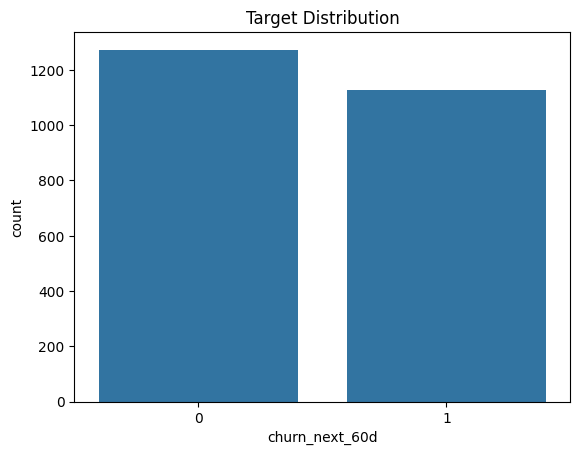

In [14]:
#Target Analysis
print('\n The value counts of churn_next_60d\n',df['churn_next_60d'].value_counts())
print('\n The percentage of value counts of churn_next_60d\n',df['churn_next_60d'].value_counts(normalize=True)*100)
#visualization
sns.countplot(data=df,x='churn_next_60d')
plt.title("Target Distribution")
plt.show()

### Leakage Prevention

The provided `rfm_modeling_snapshot.csv` was specifically engineered using information available on or before the snapshot date (2025-09-30). According to the dataset documentation, all feature columns are leakage-safe.

The following columns were excluded:

- `customer_id` (identifier only)
- `snapshot_date` (constant reference date)
- `churn_next_60d` (target variable)
- `split` (evaluation partition indicator)

All remaining variables were used as model features.

In [29]:
#Leakage Prevention
print(df.columns.tolist())
drop_cols = ['customer_id','snapshot_date','churn_next_60d','split']
X = df.drop(columns=drop_cols)
print(f'\nAfter dropping the columns we have\n')
print(X.columns.tolist())
y = df['churn_next_60d']

['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

After dropping the column we have

['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_add

In [16]:
#Provided Train/Validation/Test Split
train_df = df[df['split']=='train']
val_df = df[df['split']=='validation']
test_df = df[df['split']=='test']
print(f'the shape of train {train_df.shape}')
print(f'the shape of validation {val_df.shape}')
print(f'the shape of test {test_df.shape}')

the shape of train (1728, 29)
the shape of validation (336, 29)
the shape of test (336, 29)


In [17]:
#Create X and y
feature_cols = [col for col in df.columns
    if col not in [
        'customer_id','snapshot_date',
        'churn_next_60d','split']]

X_train = train_df[feature_cols]
y_train = train_df['churn_next_60d']

X_val = val_df[feature_cols]
y_val = val_df['churn_next_60d']

X_test = test_df[feature_cols]
y_test = test_df['churn_next_60d']

In [18]:
#Identify Column Types
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()
print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))

Categorical Features: 6
Numerical Features: 19


In [19]:
#Preprocessing Pipeline
#Numeric
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])
#Categorical
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])
#combined
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)])

In [20]:
#Baseline Model (Logistic Regression)
baseline_model = Pipeline([('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,random_state=42))])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_s...
                                                   'email_opens_30d',
                                                   'campaign_clicks_30d',
                                                   'last_visit_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [21]:
#Validation Predictions
val_pred = baseline_model.predict(X_val)
val_prob = baseline_model.predict_proba(X_val)[:,1]
print(classification_report(y_val,val_pred))
print("ROC-AUC:",roc_auc_score(y_val,val_prob))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       189
           1       0.81      0.76      0.79       147

    accuracy                           0.82       336
   macro avg       0.82      0.81      0.81       336
weighted avg       0.82      0.82      0.82       336

ROC-AUC: 0.8830219918655293


### Validation Performance Interpretation

The Logistic Regression model achieved an accuracy of 81.8% and a ROC-AUC score of 0.883 on the validation set.

For the churn class (Class 1), the model achieved:

- Precision: 81%
- Recall: 76%
- F1 Score: 79%

* This indicates that the model correctly identifies most churners while maintaining a relatively low false-positive rate.
* The ROC-AUC score of 0.883 suggests strong separation between churner and non-churner customers.

###Stronger Model: Random Forest Classifier

A Random Forest model, is trained to capture non-linear relationships and interactions between customer behaviour, engagement, support activity and purchasing patterns.

In [22]:
# Random Forest Pipeline

rf_model = Pipeline([('preprocessor', preprocessor),
    ('classifier',RandomForestClassifier(
         n_estimators=300, max_depth=8,
         min_samples_split=10,min_samples_leaf=5,
         random_state=42))])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['recency_days',
                                                   'frequency_180d',
                                                   'monetary_180d',
                                                   'return_rate_180d',
                                                   'avg_discount_pct_180d',
                                                   'avg_rating_180d',
                                                   'category_diversity_180d',
                                                   'ticket_count_90d',
                                                   'negative_ticket_rate_90d',
                                                   'avg_resolution_hours_90d',
                                                   'days_s...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_tier', 'age_group',
                                                   'acquisition_channel',
                                                   'loyalty_tier',
                                                   'preferred_category',
                                                   'marketing_consent'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])

In [45]:
#Validation Performance
rf_val_pred = rf_model.predict(X_val)
rf_val_prob = rf_model.predict_proba(X_val)[:,1]
print(classification_report(y_val, rf_val_pred))
print("ROC-AUC:",roc_auc_score(y_val, rf_val_prob))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       189
           1       0.80      0.73      0.76       147

    accuracy                           0.80       336
   macro avg       0.80      0.79      0.80       336
weighted avg       0.80      0.80      0.80       336

ROC-AUC: 0.8796746211712199


##Model Comparison
| Metric | Logistic Regression | Random Forest |
| :--- | :--- | :--- |
| **Accuracy** | 0.82 | 0.80 |
| **Precision** | 0.81 | 0.80 |
| **Recall** | 0.76 | 0.73 |
| **F1 Score** | 0.79 | 0.76 |
| **ROC-AUC** | 0.883 | 0.880 |

* The **Logistic Regression** model outperformed the **Random Forest** across all major evaluation metrics.
* Despite being a simpler model, it generalized better to the validation set and achieved higher discrimination ability as measured by ROC-AUC.
* Therefore, ***Logistic Regression*** is selected as the final model for deployment.


In [ ]:
#Threshold Selection
thresholds = np.arange(0.30,0.81,0.05)
results = []

for t in thresholds:
  pred = (val_prob >= t).astype(int)
  results.append({'threshold': t,
        'precision': precision_score(y_val,pred),
        'recall': recall_score(y_val,pred),
        'f1': f1_score(y_val,pred)})
threshold_df = pd.DataFrame(results)
threshold_df
print(f'\n Threshold table\n')
print(threshold_df.sort_values('f1',ascending=False))


## Threshold Selection Recommendation

The threshold results clearly show:

| Threshold | Precision | Recall | F1 Score |
| :---: | :---: | :---: | :---: |
| 0.40 | 0.770 | 0.844 | **0.805** |
| 0.45 | 0.799 | 0.810 | 0.804 |
| 0.50 | 0.812 | 0.762 | 0.786 |


    Recommended Threshold = 0.40

**Why?**
* **Highest F1 Score (0.805)**: Balances the trade-off optimally.
* **Highest Recall**: Captures the most potential churners among top-performing thresholds.
* **Retention**: Churn prediction is a retention problem where missing a churner (**False Negative**) is more expensive than contacting a loyal customer (**False Positive**).

> **Business Impact:** A customer incorrectly targeted with a retention campaign may receive a discount unnecessarily, but a missed churner results in permanent revenue loss.

In [ ]:
#Feature Importance (Logistic Regression)

feature_names = baseline_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = baseline_model.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({'feature': feature_names,
    'coefficient': coefficients,'abs_coef': np.abs(coefficients)
})
importance_df = importance_df.sort_values('abs_coef',
    ascending=False)
print(f'\n Top 20 feature importance table\n')
importance_df.head(20)

## Feature Importance Interpretation

The ***Logistic Regression*** coefficients indicate which features increase or decrease the likelihood of customer churn.

### Strongest Drivers of Churn

- **return_rate_180d** is the strongest positive predictor of churn.

  Customers who frequently return products are more likely to stop purchasing in the future.
- **negative_ticket_rate_90d** suggests that poor customer-service experiences increase churn risk.
- **avg_discount_pct_180d** indicates that customers who rely heavily on discounts may have weaker brand loyalty.
- **category_diversity_180d** shows that customers purchasing across many categories may exhibit less stable purchasing behaviour.

### Strongest Retention Signals

- **loyalty_tier_Platinum** reduces churn risk, indicating the value of loyalty programmes.
- **frequency_180d** demonstrates that repeat purchasing is strongly associated with retention.
- **marketing_consent_Yes** suggests that customers who engage with marketing communications are less likely to churn.
- **acquisition_channel_Organic** customers appear more loyal than customers acquired through paid channels.

These findings are broadly consistent with the exploratory data analysis, where purchasing frequency, engagement and customer satisfaction emerged as important retention drivers.

In [25]:
#Error Analysis Data
val_results = val_df.copy()
val_results['actual'] = y_val.values
val_results['predicted'] = val_pred
val_results['probability'] = val_prob
#False Positives
fp = val_results[(val_results['actual']==0) &
    (val_results['predicted']==1)]
print(f'\n 5 false positives\n')
fp[['customer_id',
'recency_days','frequency_180d',
'monetary_180d','sessions_30d',
'actual','predicted',
'probability']].head(5)


 5 false positives



,customer_id,recency_days,frequency_180d,monetary_180d,sessions_30d,actual,predicted,probability
26,CUST00027,70,1,2128.34,11,0,1,0.522833
99,CUST00100,70,1,372.37,1,0,1,0.679886
143,CUST00144,86,2,928.58,8,0,1,0.614811
176,CUST00177,82,1,255.04,12,0,1,0.737708
337,CUST00338,12,1,887.38,6,0,1,0.740171


In [26]:
#False Negatives
fn = val_results[(val_results['actual']==1) &
    (val_results['predicted']==0)]
print(f'\n 5 false negatives \n')
fn[['customer_id',
'recency_days','frequency_180d',
'monetary_180d','sessions_30d',
'actual','predicted',
'probability']].head(5)


 5 false negatives 



,customer_id,recency_days,frequency_180d,monetary_180d,sessions_30d,actual,predicted,probability
92,CUST00093,85,1,759.64,16,1,0,0.333792
144,CUST00145,30,1,502.35,0,1,0,0.477230
156,CUST00157,0,1,376.83,3,1,0,0.229615
187,CUST00188,29,2,1880.31,11,1,0,0.110037
266,CUST00267,29,1,441.97,8,1,0,0.113612


### **Error Analysis Insights**

**False Positives**

(Predicted Churn, but stayed)
* **Risk:** Incurs unnecessary retention costs (discounts, marketing outreach).

| Customer | Observation |
| :--- | :--- |
| **CUST00027** | Moderate recency but unusually high spend (₹2,128) likely indicated stronger loyalty than model expected. |
| **CUST00100** | Low spend/engagement profile falsely matched churn but remained active. |
| **CUST00144** | Recency of 86 days strongly signaled churn despite multiple purchases. |
| **CUST00177** | High engagement (12 sessions) conflicted with weak purchase history. |
| **CUST00338** | Late-stage purchase activity outweighed prior churn indicators. |

**Business Risk**: False positives create unnecessary retention costs such as discounts, coupons, or outreach campaigns.

-----

**False Negatives**

 (Predicted Stay, Actually Churned)
* **Risk:** High financial cost due to unmitigated customer and revenue loss. **This asymmetry justifies the 0.40 threshold.**


| Customer | Observation |
| :--- | :--- |
| **CUST00093** | High engagement (16 sessions) masked hidden churn behavior. |
| **CUST00145** | Misleading recent activity masked ultimate churn. |
| **CUST00157** | Recent purchase created a false retention signal. |
| **CUST00188** | Strong historical spending/frequency hid immediate churn risk. |
| **CUST00267** | Moderate engagement generated a misleading retention profile. |

**Business Risk**

False negatives are more costly because the company loses customers without triggering intervention.



In [40]:
# Test probabilities
test_prob = baseline_model.predict_proba(X_test)[:,1]
selected_threshold = 0.40
test_pred = (test_prob >= selected_threshold).astype(int)
#Classification Report
print(f'test classification report\n')
print(classification_report(y_test,test_pred))
#ROC-AUC
print("ROC-AUC:",roc_auc_score(y_test, test_prob))


test classification report

              precision    recall  f1-score   support

           0       0.86      0.76      0.80       168
           1       0.78      0.88      0.83       168

    accuracy                           0.82       336
   macro avg       0.82      0.82      0.81       336
weighted avg       0.82      0.82      0.81       336

ROC-AUC: 0.8855938208616779


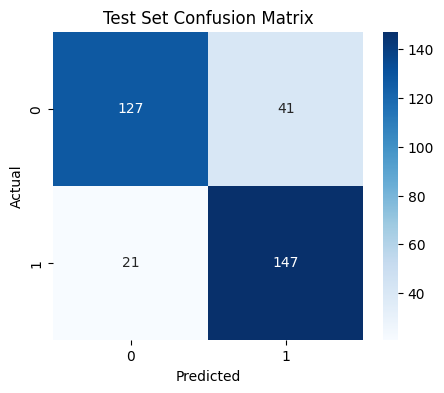

In [35]:
#Confusion matrix
cm = confusion_matrix(y_test,test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

This provides a detailed view of model performance beyond overall accuracy.

- **True Positives (147)**: Customers correctly identified as future churners.
- **True Negatives (127**): Customers correctly identified as non-churners.
- **False Positives (41)**: Customers incorrectly flagged as churn risks.
- **False Negatives (21)**: Customers predicted to stay but who ultimately churned.

From a business perspective, false negatives are more costly because they represent missed opportunities for retention.

At the **selected threshold of 0.40**, the model successfully identified 147 of 168 churning customers while missing only 21 churners, resulting in a recall of 87.5%.(metrix value)



In [39]:
#Extract Metrics for metrics.json
metrics = {"model": "Logistic Regression","threshold": 0.40,
    "accuracy": accuracy_score(y_test,test_pred),
    "precision": precision_score(y_test,test_pred),
    "recall": recall_score(y_test,test_pred),
    "f1_score": f1_score(y_test,test_pred),
    "roc_auc": roc_auc_score(y_test,test_prob),
    "confusion_matrix": {"tn": int(cm[0,0]),
        "fp": int(cm[0,1]),"fn": int(cm[1,0]),
        "tp": int(cm[1,1])}}
metrics


{'model': 'Logistic Regression',
 'threshold': 0.4,
 'accuracy': 0.8154761904761905,
 'precision': 0.7819148936170213,
 'recall': 0.875,
 'f1_score': 0.8258426966292135,
 'roc_auc': np.float64(0.8855938208616779),
 'confusion_matrix': {'tn': 127, 'fp': 41, 'fn': 21, 'tp': 147}}

In [ ]:
#Save metrics.json
import json
with open("metrics.json","w") as f: json.dump(metrics,f,indent=4)
print("metrics.json saved")

In [46]:
#final model
joblib.dump(baseline_model,"model.pkl")
print("model.pkl saved")

model.pkl saved


## Model Persistence

The final Logistic Regression model is saved as `model.pkl` to allow future scoring of customers without retraining the model.

## Final Business Conclusion

The final Logistic Regression model was evaluated on the unseen test dataset using the selected probability threshold of 0.40.

### Test Performance

- Accuracy: 81.5%
- Precision: 78.2%
- Recall: 87.5%
- F1 Score: 82.6%
- ROC-AUC: 0.886


* **Performance:** Strong predictive power with a **87.5% Recall** rate.
* **Value:** Effectively catches the majority of at-risk customers.
* **Strategy:** Minimizes costly False Negatives (missed churners) over cheaper False Positives (unnecessary outreach).


At the selected threshold, the model correctly identified 147 of 168 churning customers while missing only 21 churners.

Although 41 non-churning customers were incorrectly flagged as high risk, the business impact of these false positives is typically lower than the cost of losing a customer without intervention.

These results suggest that the model can be used to support targeted retention campaigns, proactive outreach programs, and customer success initiatives.